In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from AIce.functions import torchRMSE,trainloader,redim,getRMSE,testloader
from  AIce.models import uv256NN
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget
from time import strftime

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m



In [15]:
device='cuda'
allinput=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
#lst=['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'bath']
#weightpath='./weights/UV_5inputs_20E_0.001lr_18-13h_37m_54s.pt'

testdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_TRAIN.csv',inputlist=allinput ,target='u/v',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible

testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)

testdata['anglewind']=np.degrees(np.arctan2(testdata['u_ERA5'],testdata['v_ERA5']))

print(len(testdata))

Bath size is the full test set
Target is u/v components of the wind normalized by z-score
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
339156


300
[-177.02438376] [-0.21027832] [-4.04528849]
70.69431 -157.94894
379.0


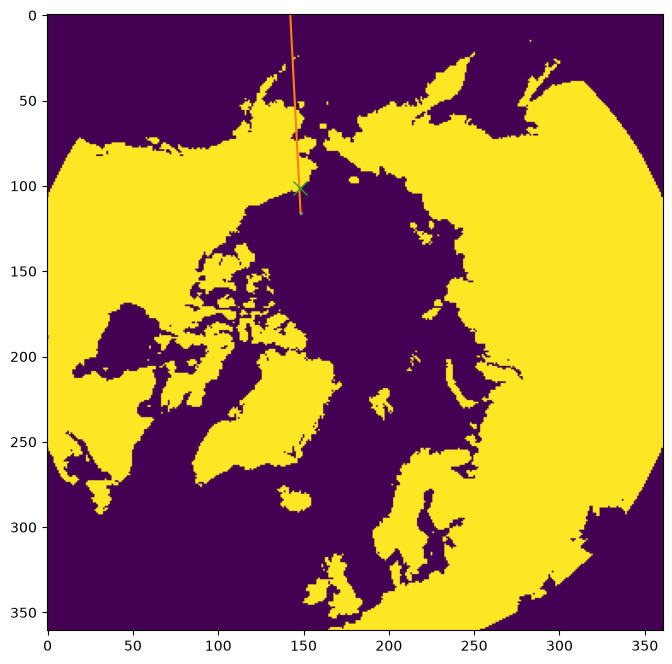

In [17]:
import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m


buoy=300#int(np.random.random()*len(testdata))
print(buoy)
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array



point=testdata.loc[testdata.index==buoy]

print(((point['anglewind'].values)),
       point['u_ERA5'].values, 
       point['v_ERA5'].values)



a=point['u_ERA5']/point['v_ERA5'] 
b=point['x_EASE']-a*point['y_EASE']


if 45>point['anglewind'].values>=-45:
    until=360
elif 135>point['anglewind'].values>=45:
    until=((360-b)/a)
elif point['anglewind'].values>=135 or point['anglewind'].values<-135:

   until=0
elif -45>=point['anglewind'].values>=-135:
   until=-b/a


y=np.linspace(point['y_EASE'],until,1000)
x=[a*i.item()+b for i in y]

ax.imshow(land)
ax.plot(point['x_EASE'],point['y_EASE'], 'x', markersize=2)
ax.plot(x,y)

inwind=np.array([y,x]).squeeze().T

roundd=np.round(inwind).astype(int)

for i in roundd:
    y_idx=i[0]
    x_idx=i[1]
    if land[y_idx,x_idx]==1:

        ax.plot(x_idx,y_idx, 'x', markersize=10)
        latland=lat_grid[y_idx,x_idx]
        lonland=lon_grid[y_idx,x_idx]
        break


latpoint=lats[buoy]
lonpoint=lons[buoy]
print(latland,lonland)
d2cwind=np.round(haversine_vectorized(latland,lonland,latpoint,lonpoint)*1e-3)
print(d2cwind)


In [ ]:
# LETS VECOTRIZE

import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array
datamask= (1-bath.isna())
# land=datamask*lands
testdata['d2cwind']= np.zeros_like(testdata['anglewind'], dtype=np.float32)



# ok so to vectorize the previous loop and not take 28 hours, we can skip the for loop by changing our approach
# instead of generating the entire line and then checking where is the closest land along that line, we can generate 
dx , dy = testdata['u_ERA5']/testdata['windnorm'], testdata['v_ERA5']/testdata['windnorm'] 
dx,dy=dx.to_numpy(),dy.to_numpy()

DL=500
LONGEST=int(360*np.sqrt(2))
t=np.linspace(0,LONGEST,DL).reshape((-1,1))

y=testdata['y_EASE'].to_numpy()+dy*t
x=testdata['x_EASE'].to_numpy()+dx*t

yi,xi=np.round(y).astype(int), np.round(x).astype(int) # np.clip(np.round(y).astype(int),0,360), np.clip(np.round(x).astype(int),0,360) # ok now I have the index of the lines in the direction of the wind until they hit the side of the grid where they clip




padded=np.pad(datamask, LONGEST, mode= 'constant')

yc=padded[(yi+LONGEST,xi+LONGEST)]*yi
xc=padded[(yi+LONGEST,xi+LONGEST)]*xi
landy=land[(yc,xc)]*yc
landx=land[(yc,xc)]*xc

landhit=[]

for k in range(testdata.shape[0]):
    for i in range(DL):
        xx=landx[i,k]
        yy=landy[i,k]
        if xx or yy !=0:
            landhit.append([lat_grid[int(yy),int(xx)],lon_grid[int(yy),int(xx)]])
            break
        if i+1==DL:
            landhit.append([np.nan,np.nan])
            break

landhit=np.array(landhit).T #((lat,lons), buoy)


print(landhit.shape)

d2cwind=np.round(haversine_vectorized(landhit[0],landhit[1],lats,lons))

testdata['d2cwind']=d2cwind
testdata.columns
# # testdata.to_csv('TestsetD2C.csv', mode='w')

(2, 339156)


Index(['u_buoy', 'v_buoy', 'x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR',
       'h_piomas', 'sin', 'cos', 'bath', 'windnorm', 'anglewind', 'd2cwind'],
      dtype='str')

805.614


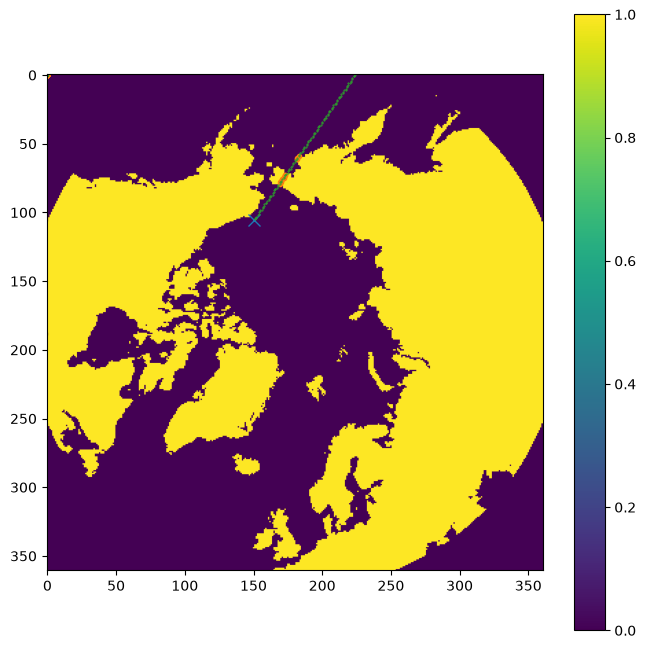

509


In [66]:
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

#ax.imshow(np.pad(datamask,LONGEST,mode= 'constant'))
im=ax.imshow(land)
a=int(np.random.random()*testdata.shape[0])
print(d2cwind[a]*1e-3)
# ax.imshow(land)
ax.plot(testdata['x_EASE'][a],testdata['y_EASE'][a], 'x', markersize=8)
# ax.plot(xc[:,a]+LONGEST,yc[:,a]+LONGEST,'.')
ax.plot(landx[:,a],landy[:,a],'.')
ax.plot(xc[:,a],yc[:,a],'.',markersize=1)
#ax.plot(landhit[0][a],landhit[1][a],'x',markersize=20)
plt.colorbar(im)
plt.show()

print(LONGEST)



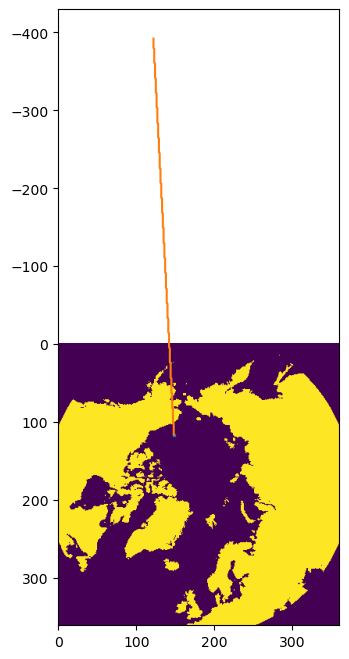

In [32]:


fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)
a=300#int(np.random.random()*testdata.shape[0])
ax.imshow(land)
ax.plot(testdata['x_EASE'][a],testdata['y_EASE'][a], 'x', markersize=2)
ax.plot(xi[:,a],yi[:,a])

In [6]:
yi[:,a].shape

(1000,)

80047


KeyboardInterrupt: 

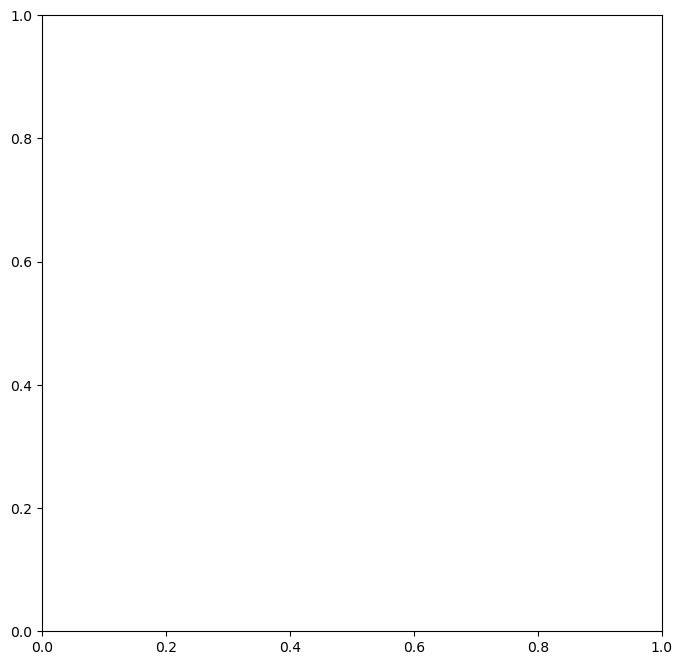

In [5]:
import cartopy.crs as ccrs 

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    All inputs in degrees, can be arrays
    Returns distance in m
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c  # m


buoy=int(np.random.random()*len(testdata))
print(buoy)
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=100,
    #subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

bath=pd.read_csv('../data/bathymetry_EASE.csv', header= None)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# # (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

#datamask= (1-bath.isna()) # make sure to check where we have data
land=(bath.where(bath==3000,2999)-2999).to_numpy().astype(np.float32) # getting a land numpy array

a=testdata['u_ERA5']/testdata['v_ERA5'] 
b=testdata['x_EASE']-a*testdata['y_EASE']


until=[360 if 45>i>=-45 else ((360-b)/a) if  135>i>=45 else 0 if i>=135 or i<-135 else -b/a for i in testdata['anglewind'].values]

y=np.linspace(point['y_EASE'],until,1000)
x=[a*i.item()+b for i in y]

ax.imshow(land)
ax.plot(point['x_EASE'],point['y_EASE'], 'x', markersize=2)
ax.plot(x,y)

inwind=np.array([y,x]).squeeze().T

roundd=np.round(inwind).astype(int)

for i in roundd:
    y_idx=i[0]
    x_idx=i[1]
    if land[y_idx,x_idx]==1:

        ax.plot(x_idx,y_idx, 'x', markersize=10)
        latland=lat_grid[y_idx,x_idx]
        lonland=lon_grid[y_idx,x_idx]
        break


latpoint=lats[buoy]
lonpoint=lons[buoy]
print(latland,lonland)
d2cwind=np.round(haversine_vectorized(latland,lonland,latpoint,lonpoint)*1e-3)
print(d2cwind)

Your until conditional is a chain of if/elif on a scalar, which is the same logic as np.select on arrays. Compute all the branches, then pick per row with the sector conditions:

python
u   = testdata['u_ERA5'].values
v   = testdata['v_ERA5'].values
y0  = testdata['y_EASE'].values.astype(float)
x0  = testdata['x_EASE'].values.astype(float)
ang = testdata['anglewind'].values

with np.errstate(divide='ignore', invalid='ignore'):
    a = u / v
    b = x0 - a * y0
    until = np.select(
        [(ang >= -45)  & (ang < 45),
         (ang >= 45)   & (ang < 135),
         (ang >= 135)  | (ang < -135)],
        [360,
         (360 - b) / a,
         0],
        default=-b / a)          # the -135 <= ang < -45 sector

The conditions follow your original ones (including -135 falling in the last sector). Use plain NumPy arrays (.values) rather than Series, so the shapes behave when you broadcast later.

The rest of the vectorized pipeline

Your pasted code still has some leftovers from the loop version that will break. The x=[a*i.item()+b for i in y] list comprehension doesn't work on a 2D array, and buoy no longer exists. Here is the broadcast version:

python
N = len(testdata)

y = np.linspace(y0, until, 1000)      # (1000, N): one column per buoy
x = a * y + b                         # (1000, N), broadcasts over columns

yi = np.round(y).astype(int)
xi = np.round(x).astype(int)

# You can't drop points anymore, since each column needs its own length.
# Mask them instead, and clip so that indexing doesn't fail.
inside = (yi >= 0) & (yi <= 360) & (xi >= 0) & (xi <= 360)
yc = np.clip(yi, 0, 360)
xc = np.clip(xi, 0, 360)

hit = (land[yc, xc] == 1) & inside    # (1000, N)
has_hit = hit.any(axis=0)             # did this buoy hit land at all?
first = hit.argmax(axis=0)            # index of first True along the path
cols = np.arange(N)

yl = yc[first, cols]
xl = xc[first, cols]

latland = np.where(has_hit, lat_grid[yl, xl], np.nan)
lonland = np.where(has_hit, lon_grid[yl, xl], np.nan)

d2c = np.round(haversine_vectorized(latland, lonland, lats, lons) * 1e-3)
testdata['d2cwind'] = d2c.astype(np.float32)
testdata.to_csv('TrainsetD2C.csv', mode='w')

Remove the buoy lines (lats[buoy], the testdata.loc[...] assignment, and the percent print), since this computes all buoys at once. argmax on a boolean array returns the first True, and because the points are ordered from the buoy outward, that is the nearest land hit. Where has_hit is False, first is 0, but the np.where replaces that with NaN.

land[y,x]